# Model comparison — MVP / VAE / FSMN-AE / TET

Runs a **fair reconstruction-head comparison** on shared data, seed, window (20),
stride (20), and attack families, then plots headline metrics plus a feature correlation heatmap.

Outputs land in `../figures/` (relative to this notebook when run from `Python scripts/`).

```bash
# Or from the CLI:
python compare_models.py ../Data/new_data_processed
```

In [1]:
from pathlib import Path
import subprocess
import sys

SCRIPTS = Path.cwd()
if (SCRIPTS / "compare_models.py").exists():
    ROOT = SCRIPTS
elif (SCRIPTS / "Python scripts" / "compare_models.py").exists():
    ROOT = SCRIPTS / "Python scripts"
else:
    ROOT = Path("Python scripts").resolve()

DATA = ROOT.parent / "Data" / "new_data_processed"
OUT = ROOT / "figures"
print("ROOT", ROOT)
print("DATA", DATA, "exists=", DATA.exists())

ROOT /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts
DATA /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Data/new_data_processed exists= True


In [2]:
cmd = [
    sys.executable,
    str(ROOT / "compare_models.py"),
    str(DATA),
    "--max-windows", "10000",
    "--latency-n", "400",
    "--outdir", str(OUT),
]
print(" ".join(cmd))
subprocess.run(cmd, check=True, cwd=str(ROOT))

/Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/bin/python3.14 /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/compare_models.py /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Data/new_data_processed --max-windows 10000 --latency-n 400 --outdir /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/figures
[Config] window=20 stride=20 attack_rate=0.3 max_windows=10000 latency_n=40

CompletedProcess(args=['/Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/bin/python3.14', '/Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/compare_models.py', '/Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Data/new_data_processed', '--max-windows', '10000', '--latency-n', '400', '--outdir', '/Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/figures'], returncode=0)

,model,PR AUC,AUROC,macro F1,MCC,recall,FPR,params,size_kib,latency_p50_us,latency_p99_us,prevalence
0,MVP (GRU-AE),0.798,0.858,0.799,0.601,0.750,0.120,8136,31.781,56.125,68.752,0.231
1,VAE,0.593,0.735,0.718,0.511,0.378,0.015,39708,155.109,104.208,135.817,0.231
2,FSMN-AE,0.755,0.807,0.825,0.682,0.582,0.013,7080,27.656,67.958,142.827,0.231
3,TET,0.773,0.863,0.793,0.608,0.555,0.034,68080,265.938,169.666,242.857,0.231


feature_heatmap.png


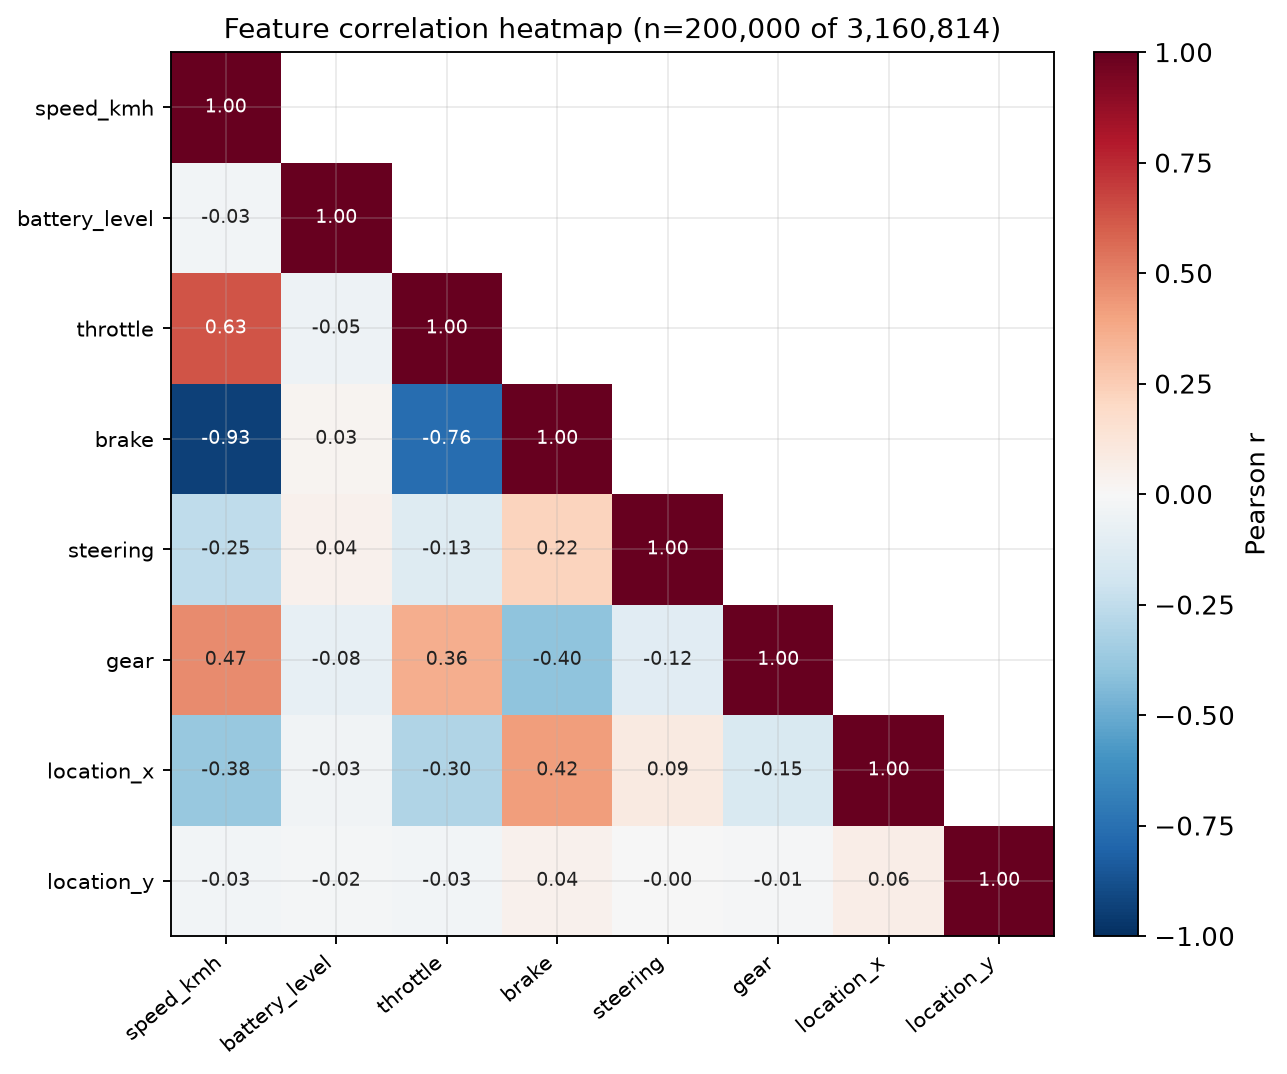

headline_comparison.png


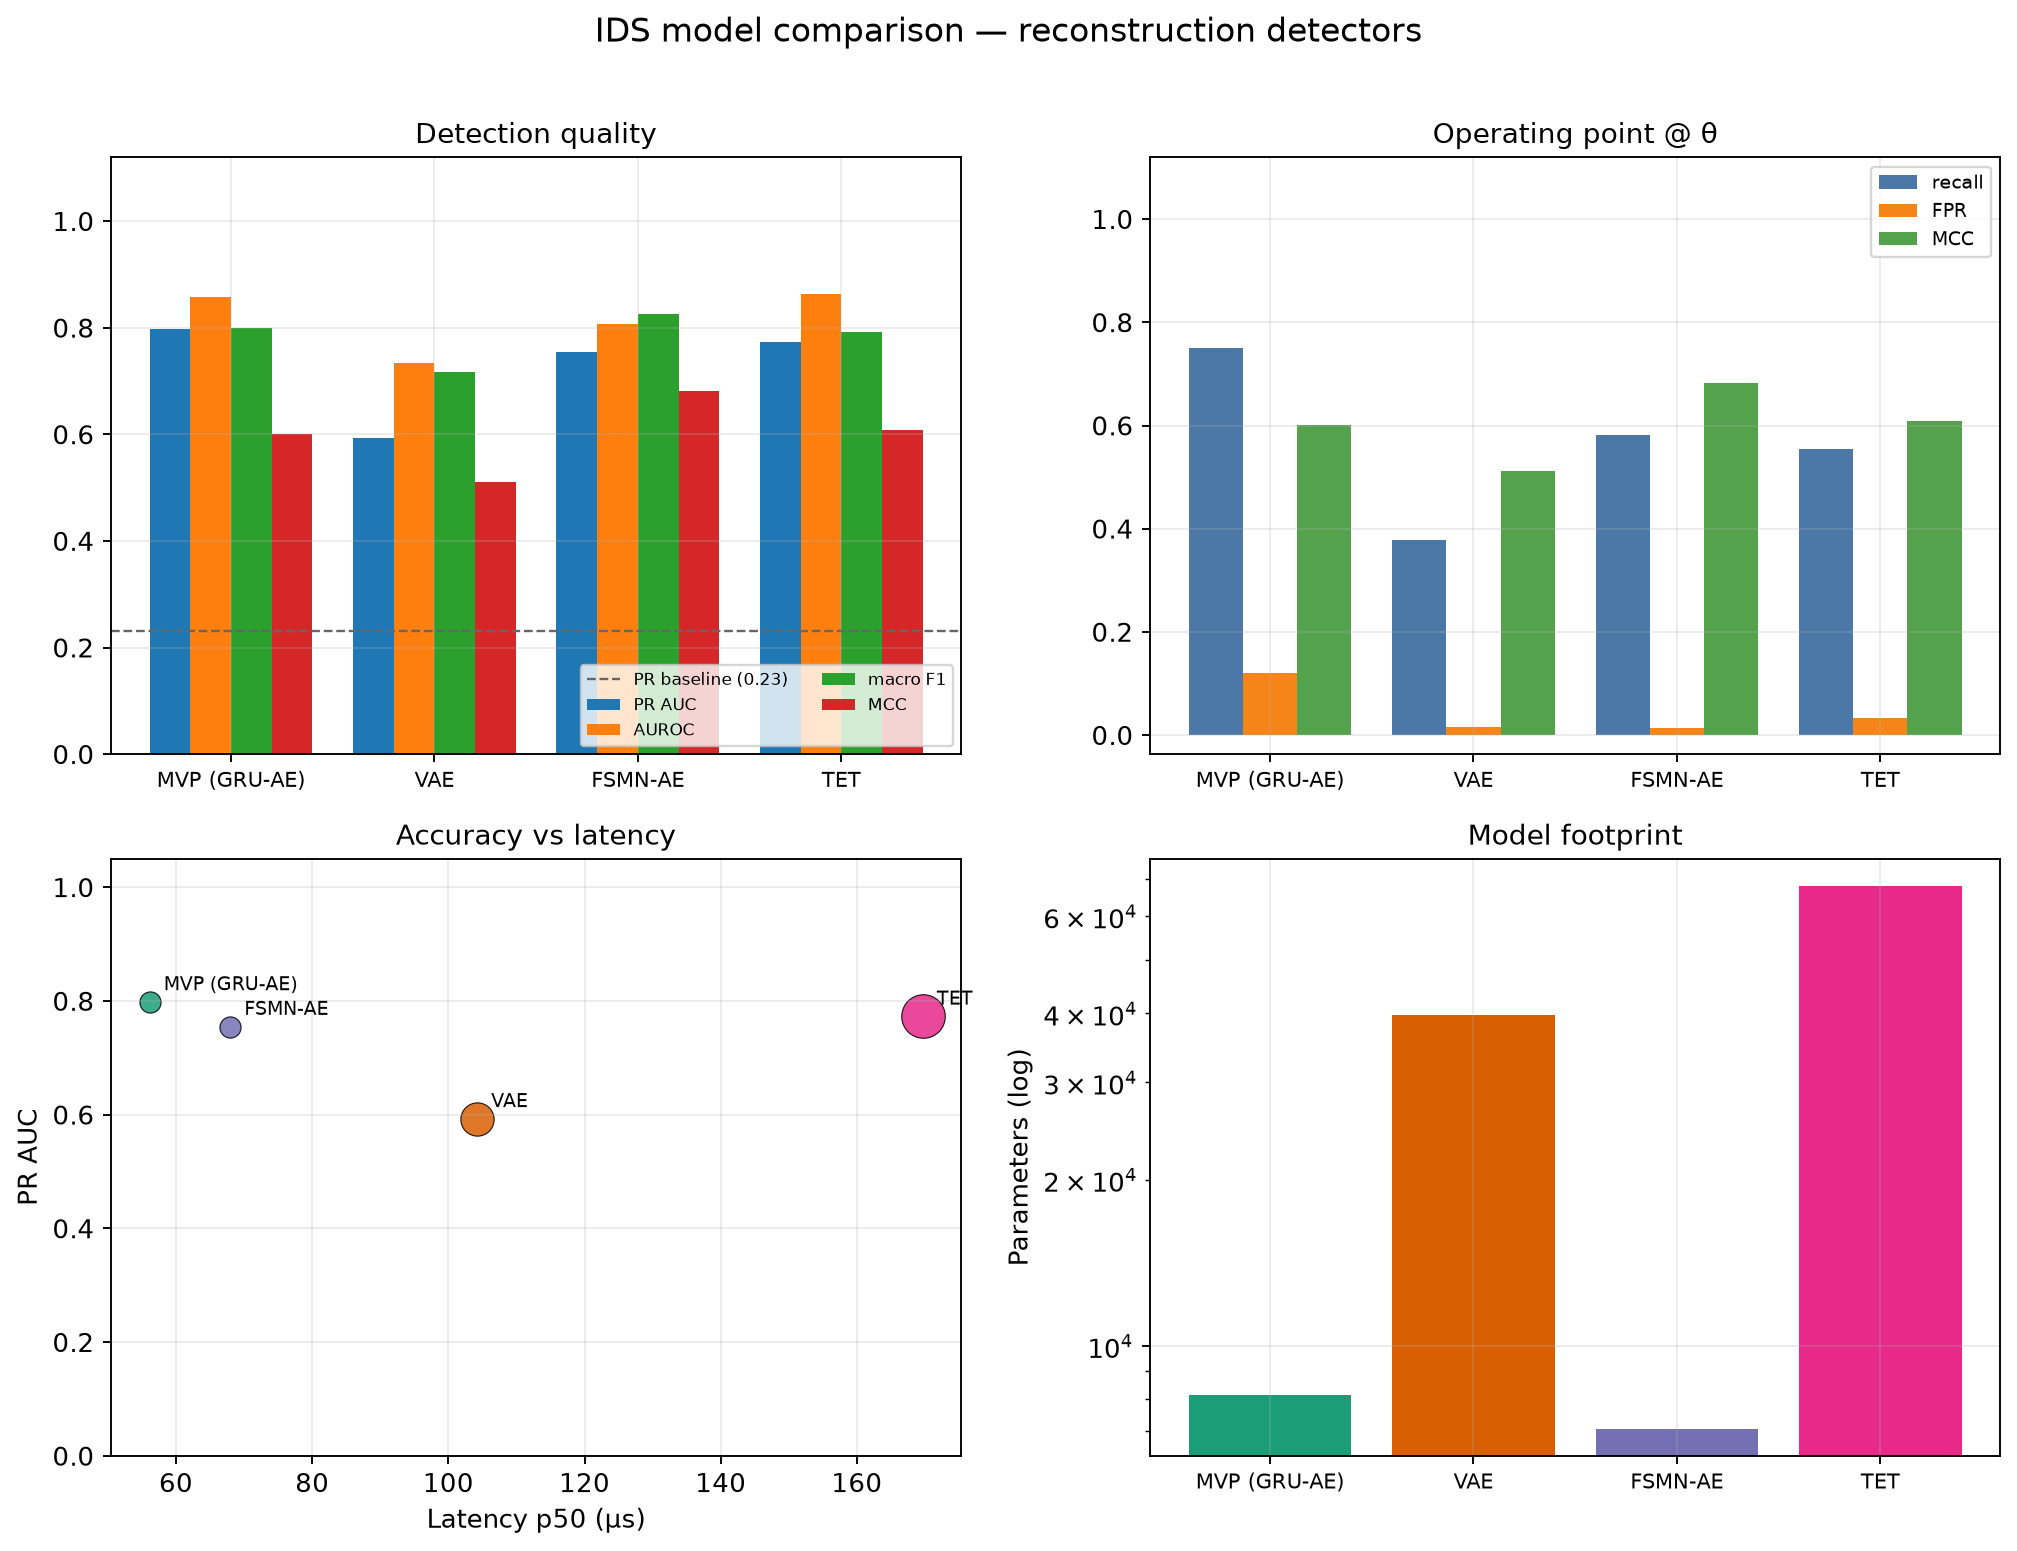

detection_quality.png


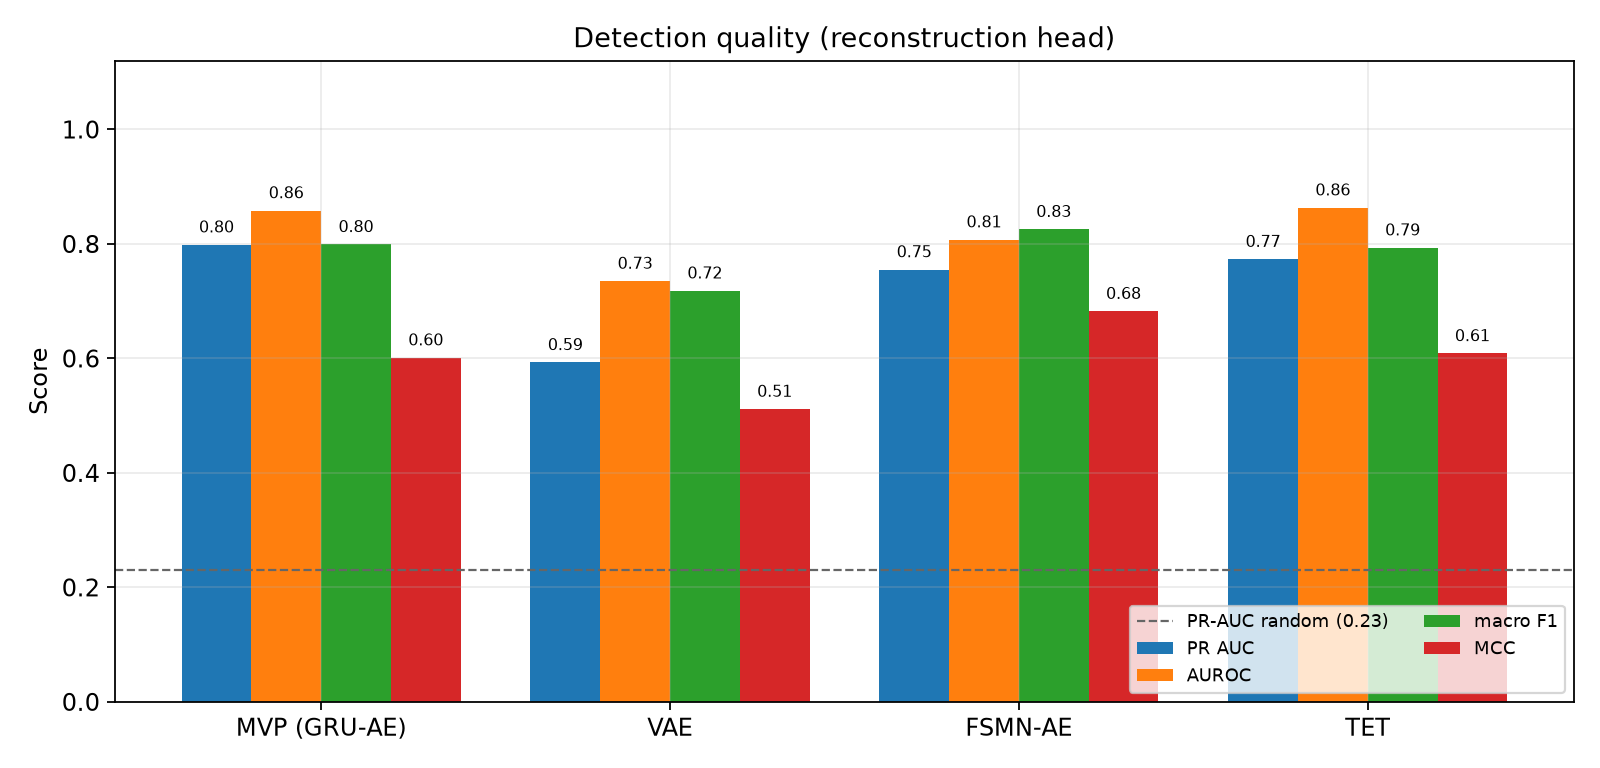

operating_point.png


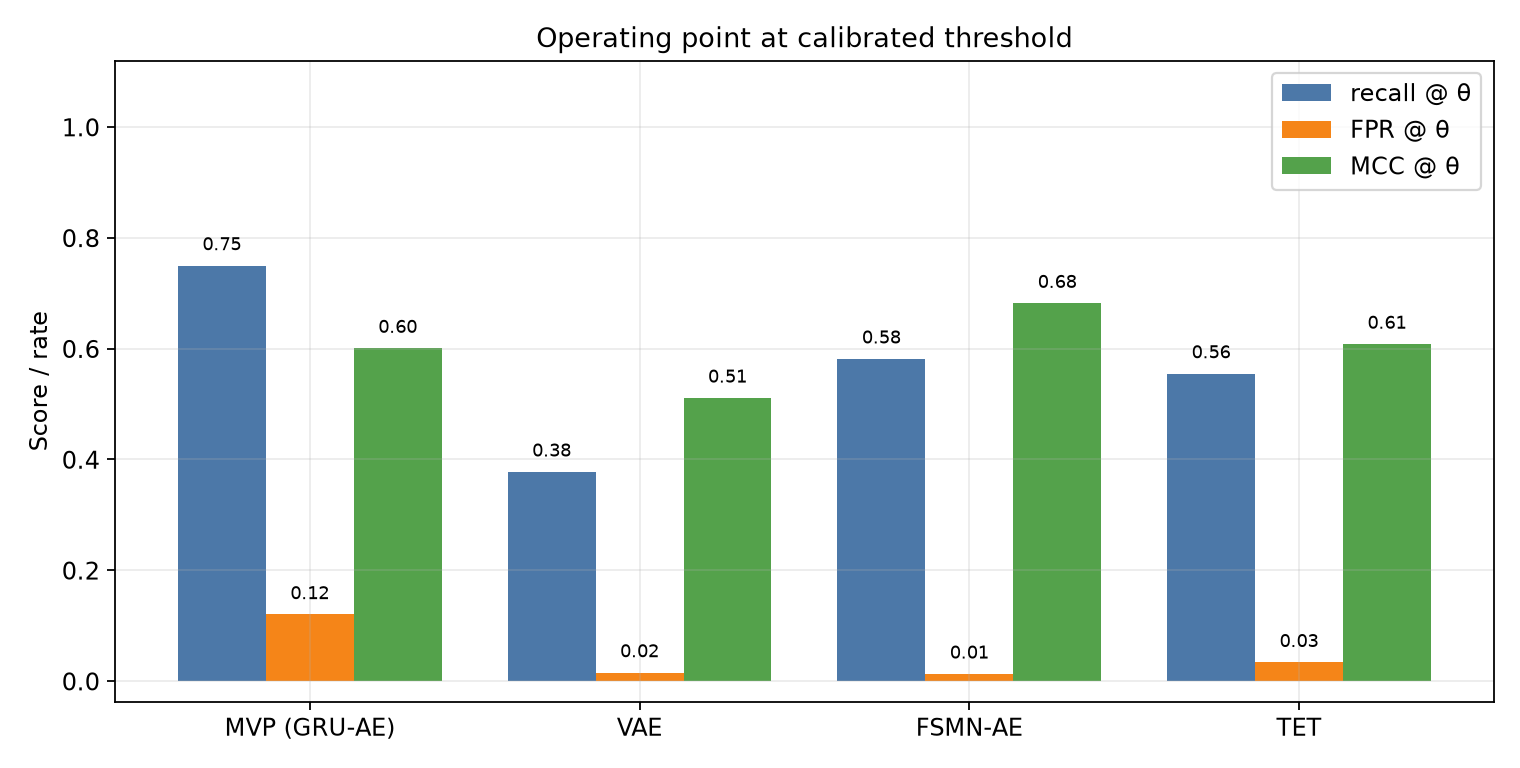

accuracy_vs_cost.png


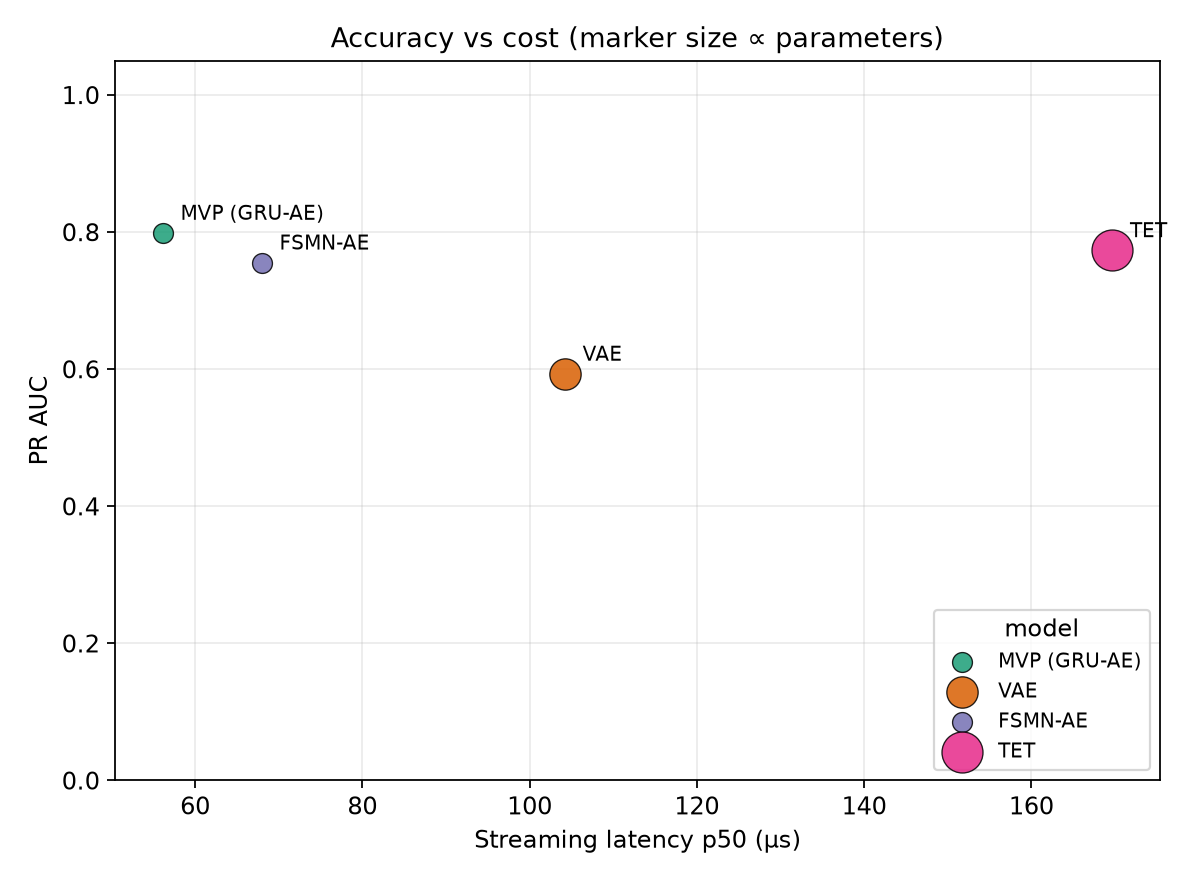

footprint.png


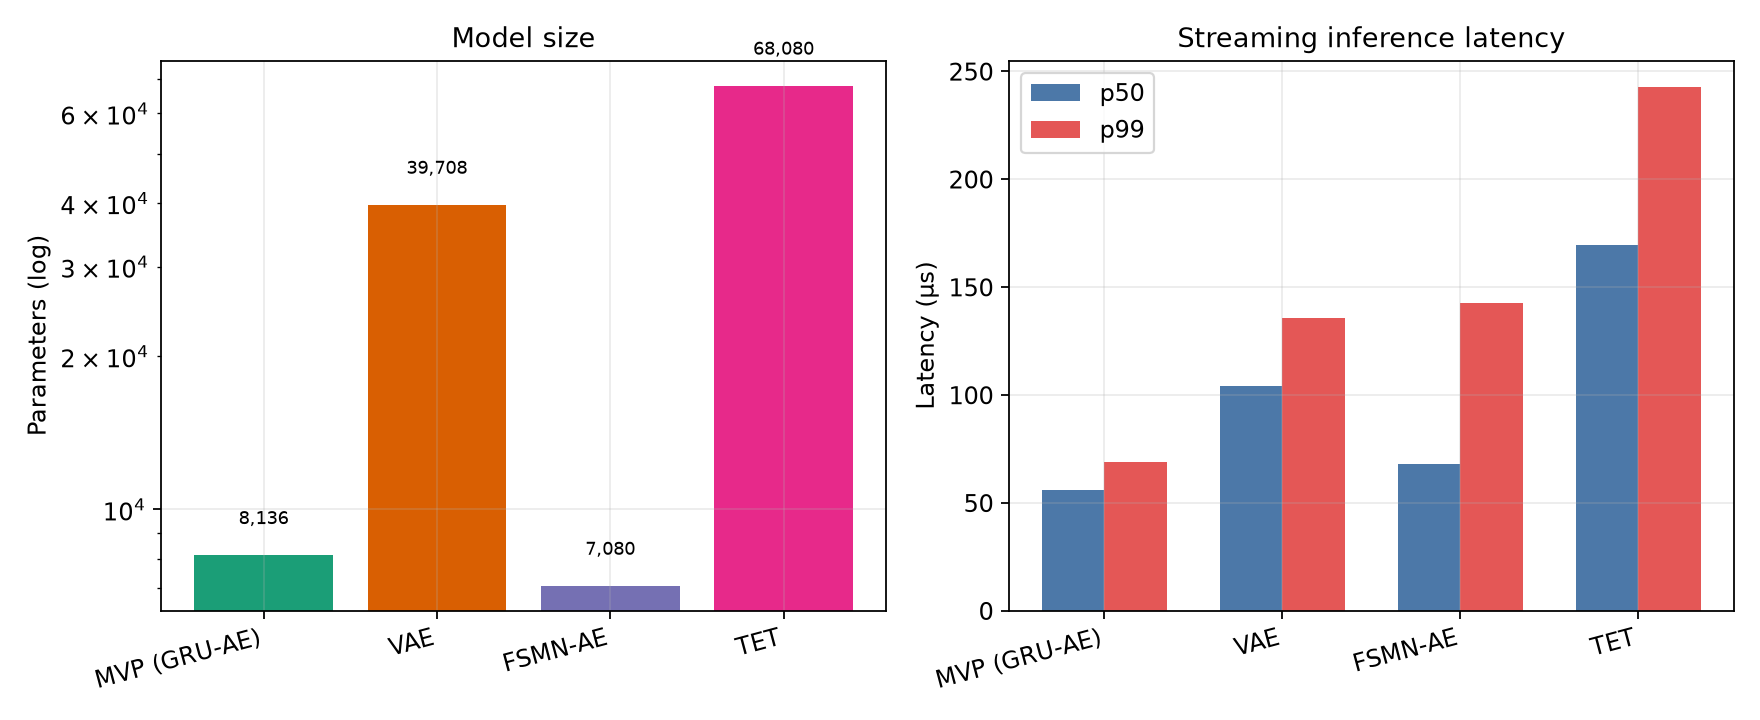

In [3]:
import pandas as pd
from IPython.display import Image, display

metrics = pd.read_csv(OUT / "metrics.csv")
display(metrics.round(3))

for name in [
    "feature_heatmap.png",
    "headline_comparison.png",
    "detection_quality.png",
    "operating_point.png",
    "accuracy_vs_cost.png",
    "footprint.png",
]:
    path = OUT / name
    print(path.name)
    display(Image(filename=str(path)))